# EDA for Customer Loyalty 

In [1]:
# importing the basic modules 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import seaborn as sb

print("Libraries imported.")

Libraries imported.


In [2]:
loyalty_data = pd.DataFrame()

loyalty_data = pd.read_csv('../data/customer_loyalty_history.csv')

loyalty_data.tail(10)

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
16727,546773,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Married,Star,52811.49,Standard,2015,9,NaN,NaN
16728,302628,Canada,Quebec,Tremblant,H5Y 2S9,Male,Bachelor,61718.0,Single,Star,55277.45,Standard,2013,3,NaN,NaN
16729,302460,Canada,British Columbia,Whistler,V6T 1Y8,Female,Bachelor,88425.0,Married,Star,56675.94,Standard,2014,9,NaN,NaN
16730,672917,Canada,Ontario,Toronto,M1R 4K3,Female,Bachelor,76778.0,Single,Star,58166.55,Standard,2015,1,2015.0,9.0
16731,900501,Canada,Ontario,Sudbury,M5V 1G5,Male,College,NaN,Single,Star,61134.68,Standard,2012,9,NaN,NaN
16732,823768,Canada,British Columbia,Vancouver,V6E 3Z3,Female,College,NaN,Married,Star,61850.19,Standard,2012,12,NaN,NaN
16733,680886,Canada,Saskatchewan,Regina,S1J 3C5,Female,Bachelor,89210.0,Married,Star,67907.27,Standard,2014,9,NaN,NaN
16734,776187,Canada,British Columbia,Vancouver,V5R 1W3,Male,College,NaN,Single,Star,74228.52,Standard,2014,3,NaN,NaN
16735,906428,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,NaN,NaN
16736,652627,Canada,Manitoba,Winnipeg,R2C 0M5,Female,Bachelor,75049.0,Married,Star,83325.38,Standard,2015,12,2016.0,8.0


# Data Sanity Checks

In [3]:
loyalty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [4]:
# Standardize column names to snake_case

loyalty_data = loyalty_data.rename(columns = { 'Loyalty Number' : 'loyalty_number', 'Country' : 'country',
                                              'Province' : 'province', 'City':'city', 'Postal Code' : 'postal_code', 'Gender':'gender', 'Education':'education',
                                              'Salary' : 'salary', 'Marital Status': 'marital_status', 'Loyalty Card':'loyalty_card', 'CLV':'clv', 
                                              'Enrollment Type':'enrollment_type', 'Enrollment Year':'enrollment_year', 'Enrollment Month':'enrollment_month', 
                                              'Cancellation Year':'cancellation_year','Cancellation Month':'cancellation_month'
})

loyalty_data.head()

,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [5]:
# Handle nulls — fill NaN cancellations with 0, then cast to int

loyalty_data = loyalty_data.fillna(0)
loyalty_data = loyalty_data.astype({'salary': int ,'cancellation_year': int, 'cancellation_month': int}) 
loyalty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loyalty_number      16737 non-null  int64  
 1   country             16737 non-null  object 
 2   province            16737 non-null  object 
 3   city                16737 non-null  object 
 4   postal_code         16737 non-null  object 
 5   gender              16737 non-null  object 
 6   education           16737 non-null  object 
 7   salary              16737 non-null  int64  
 8   marital_status      16737 non-null  object 
 9   loyalty_card        16737 non-null  object 
 10  clv                 16737 non-null  float64
 11  enrollment_type     16737 non-null  object 
 12  enrollment_year     16737 non-null  int64  
 13  enrollment_month    16737 non-null  int64  
 14  cancellation_year   16737 non-null  int64  
 15  cancellation_month  16737 non-null  int64  
dtypes: f

In [6]:
#Combine year and month to create date strings

loyalty_data['date_str_e'] = loyalty_data['enrollment_year'].astype(str) + '-' + loyalty_data['enrollment_month'].astype(str).str.zfill(2)
loyalty_data['date_str_c'] = loyalty_data['cancellation_year'].astype(str) + '-' + loyalty_data['cancellation_month'].astype(str).str.zfill(2)

# Parse to datetime, then format back to YYYY-MM string
loyalty_data['enrollment_date'] = pd.to_datetime(loyalty_data['date_str_e'], format='%Y-%m').dt.strftime('%Y-%m')
loyalty_data['cancellation_date'] = pd.to_datetime(loyalty_data['date_str_c'], format='%Y-%m',  errors='coerce').dt.strftime('%Y-%m')

# Drop the temp string columns used for date construction
loyalty_data.drop(columns=['date_str_e', 'date_str_c'], inplace=True)

# Preview
loyalty_data.head(20)


,loyalty_number,country,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,clv,enrollment_type,enrollment_year,enrollment_month,cancellation_year,cancellation_month,enrollment_date,cancellation_date
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236,Married,Star,3839.14,Standard,2016,2,0,0,2016-02,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,0,Divorced,Star,3839.61,Standard,2016,3,0,0,2016-03,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,0,Single,Star,3839.75,Standard,2014,7,2018,1,2014-07,2018-01
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,0,Single,Star,3839.75,Standard,2013,2,0,0,2013-02,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495,Married,Star,3842.79,Standard,2014,10,0,0,2014-10,NaN
5,193662,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,51124,Married,Star,3844.57,Standard,2012,5,0,0,2012-05,NaN
6,927943,Canada,Ontario,Toronto,P5S 6R4,Female,College,0,Single,Star,3857.95,Standard,2014,6,0,0,2014-06,NaN
7,188893,Canada,Ontario,Trenton,K8V 4B2,Male,Bachelor,100159,Married,Star,3861.49,Standard,2016,12,0,0,2016-12,NaN
8,852392,Canada,Quebec,Montreal,H2Y 2W2,Female,Bachelor,100159,Married,Star,3861.49,Standard,2015,5,0,0,2015-05,NaN
9,866307,Canada,Ontario,Toronto,M8Y 4K8,Male,Bachelor,100159,Married,Star,3861.49,Standard,2016,10,0,0,2016-10,NaN


In [7]:
loyalty_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loyalty_number      16737 non-null  int64  
 1   country             16737 non-null  object 
 2   province            16737 non-null  object 
 3   city                16737 non-null  object 
 4   postal_code         16737 non-null  object 
 5   gender              16737 non-null  object 
 6   education           16737 non-null  object 
 7   salary              16737 non-null  int64  
 8   marital_status      16737 non-null  object 
 9   loyalty_card        16737 non-null  object 
 10  clv                 16737 non-null  float64
 11  enrollment_type     16737 non-null  object 
 12  enrollment_year     16737 non-null  int64  
 13  enrollment_month    16737 non-null  int64  
 14  cancellation_year   16737 non-null  int64  
 15  cancellation_month  16737 non-null  int64  
 16  enro

# EDA

### Split of card type by City

In [8]:
# Count customers per city per loyalty card
card_type_temp = loyalty_data.groupby(['city', 'loyalty_card']).size().reset_index(name='count_of_customers')

# Pivot so each loyalty card becomes a column
card_type_split = card_type_temp.pivot(index='city', columns='loyalty_card', values='count_of_customers')

# Fill missing city/card combos with 0
card_type_split = card_type_split.fillna(0).astype(int)

card_type_split['total'] = card_type_split.sum(axis=1)

card_type_split.sort_values(by=['total'],ascending=False).head(10)



loyalty_card,Aurora,Nova,Star,total
city,,,,
Toronto,719,1123,1509,3351
Vancouver,526,869,1187,2582
Montreal,412,693,954,2059
Winnipeg,145,210,303,658
Whistler,114,183,285,582
Halifax,105,180,233,518
Ottawa,119,173,217,509
Trenton,91,153,242,486
Edmonton,121,173,192,486


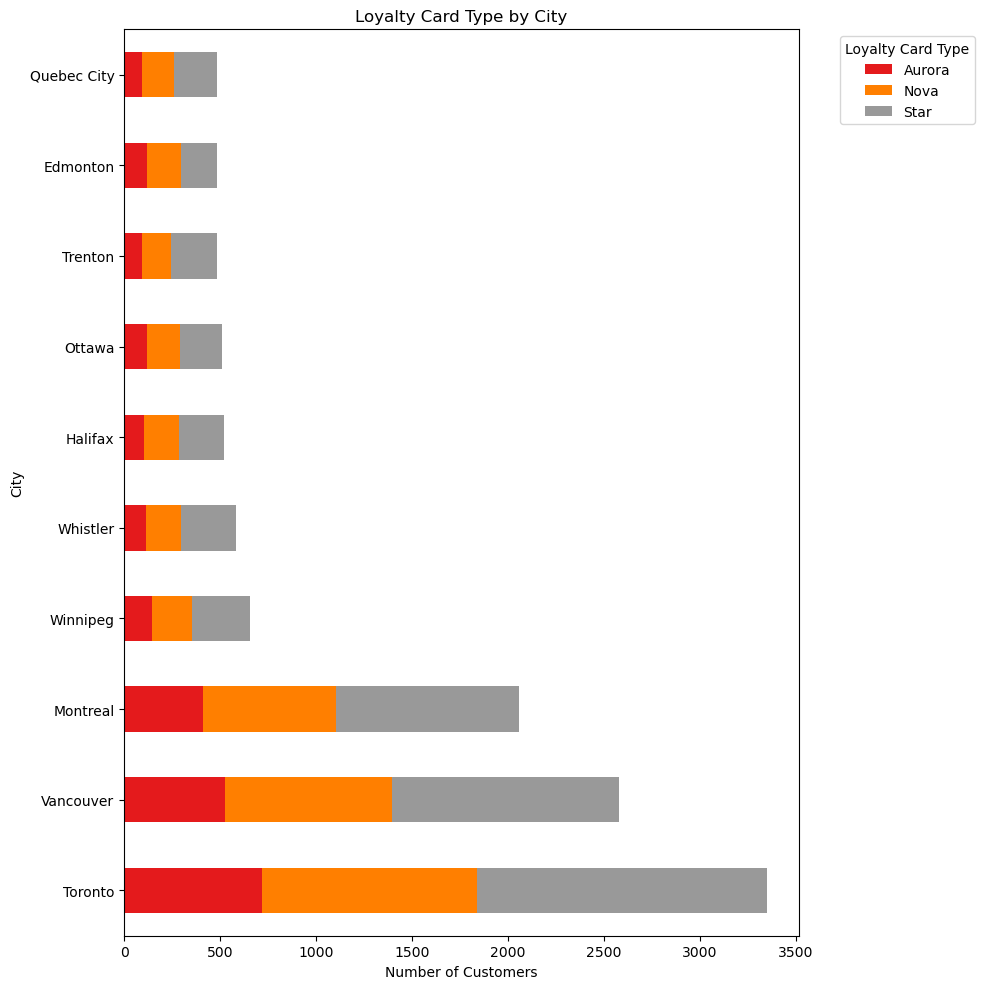

In [9]:
card_type_split_plt = card_type_split.sort_values(by=['total'],ascending=False).head(10).drop(columns='total')
#card_type_split_plt = card_type_split_plt.drop(columns='total')

ax = card_type_split_plt.plot(kind='barh', stacked=True, figsize=(10,10), colormap='Set1')

plt.title("Loyalty Card Type by City")
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.legend(title='Loyalty Card Type', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()


### Split of Customers by Enrollment Type

In [10]:
loyalty_data['enrollment_type'].unique()

array(['Standard', '2018 Promotion'], dtype=object)

In [11]:
enrollment_type_temp = loyalty_data.groupby(['city','enrollment_type']).size().reset_index(name='count_of_customers')

enrollment_type_split = enrollment_type_temp.pivot(index='city',columns='enrollment_type',values='count_of_customers')

enrollment_type_split = enrollment_type_split.fillna(0).astype(int)

enrollment_type_split['Total'] = enrollment_type_split.sum(axis=1) 

enrollment_type_split = enrollment_type_split.sort_values(by='Total',ascending=False).head(10)

enrollment_type_split

enrollment_type,2018 Promotion,Standard,Total
city,,,
Toronto,173,3178,3351
Vancouver,151,2431,2582
Montreal,138,1921,2059
Winnipeg,20,638,658
Whistler,29,553,582
Halifax,19,499,518
Ottawa,32,477,509
Trenton,29,457,486
Edmonton,23,463,486


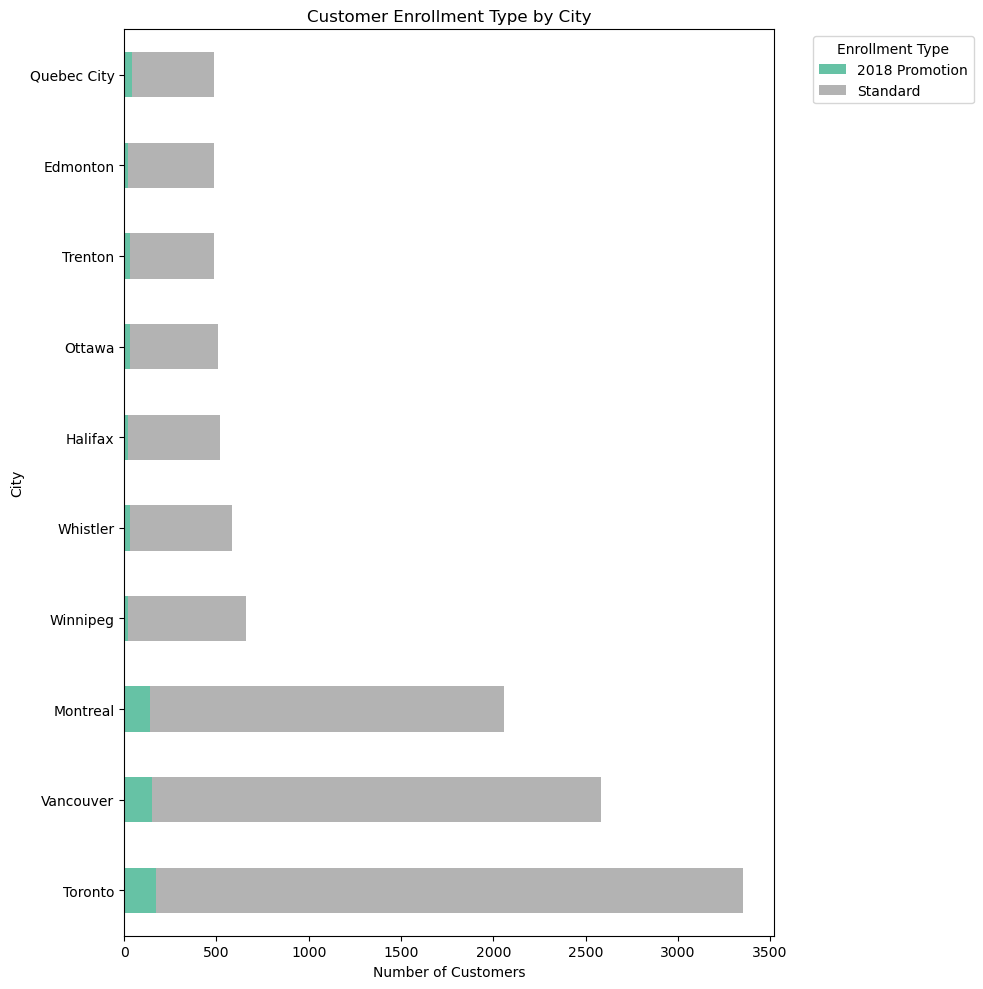

In [12]:
enrollment_type_spli_plt = enrollment_type_split.sort_values(by='Total',ascending=False).drop(columns='Total')

ax = enrollment_type_spli_plt.plot(kind='barh', stacked=True, figsize=(10,10), colormap='Set2')

plt.title('Customer Enrollment Type by City')
plt.xlabel('Number of Customers')
plt.ylabel('City')
plt.legend(title='Enrollment Type', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

### CLV Analysis


In [13]:
loyalty_data['marital_status'].unique()

array(['Married', 'Divorced', 'Single'], dtype=object)

In [14]:
# CLV aggregated by loyalty card type 

clv_by_card = loyalty_data.groupby('loyalty_card')['clv'].agg(total_clv = 'sum',
                                                              avg_clv = 'mean', median_clv = 'median').reset_index()

clv_by_card[['total_clv','avg_clv','median_clv']] = clv_by_card[['total_clv','avg_clv','median_clv']].round(2)

clv_by_card = clv_by_card.sort_values(by='total_clv',ascending=False)

clv_by_card


,loyalty_card,total_clv,avg_clv,median_clv
2,Star,51486831.60,6741.76,4786.89
1,Nova,45626688.31,8045.62,5799.06
0,Aurora,36596641.41,10672.69,8140.00


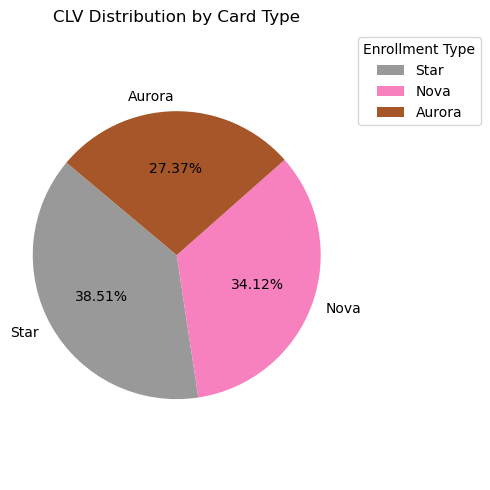

In [15]:
plt.figure(figsize=(5,5))

plt.pie(clv_by_card['total_clv'],
        labels=clv_by_card['loyalty_card'],
        autopct='%1.2f%%',
        startangle=140,
        colors=plt.cm.Set1_r.colors)

plt.title('CLV Distribution by Card Type')
plt.axis('equal')
plt.legend(title='Enrollment Type', bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()

### Enrollment Trend by Card Type

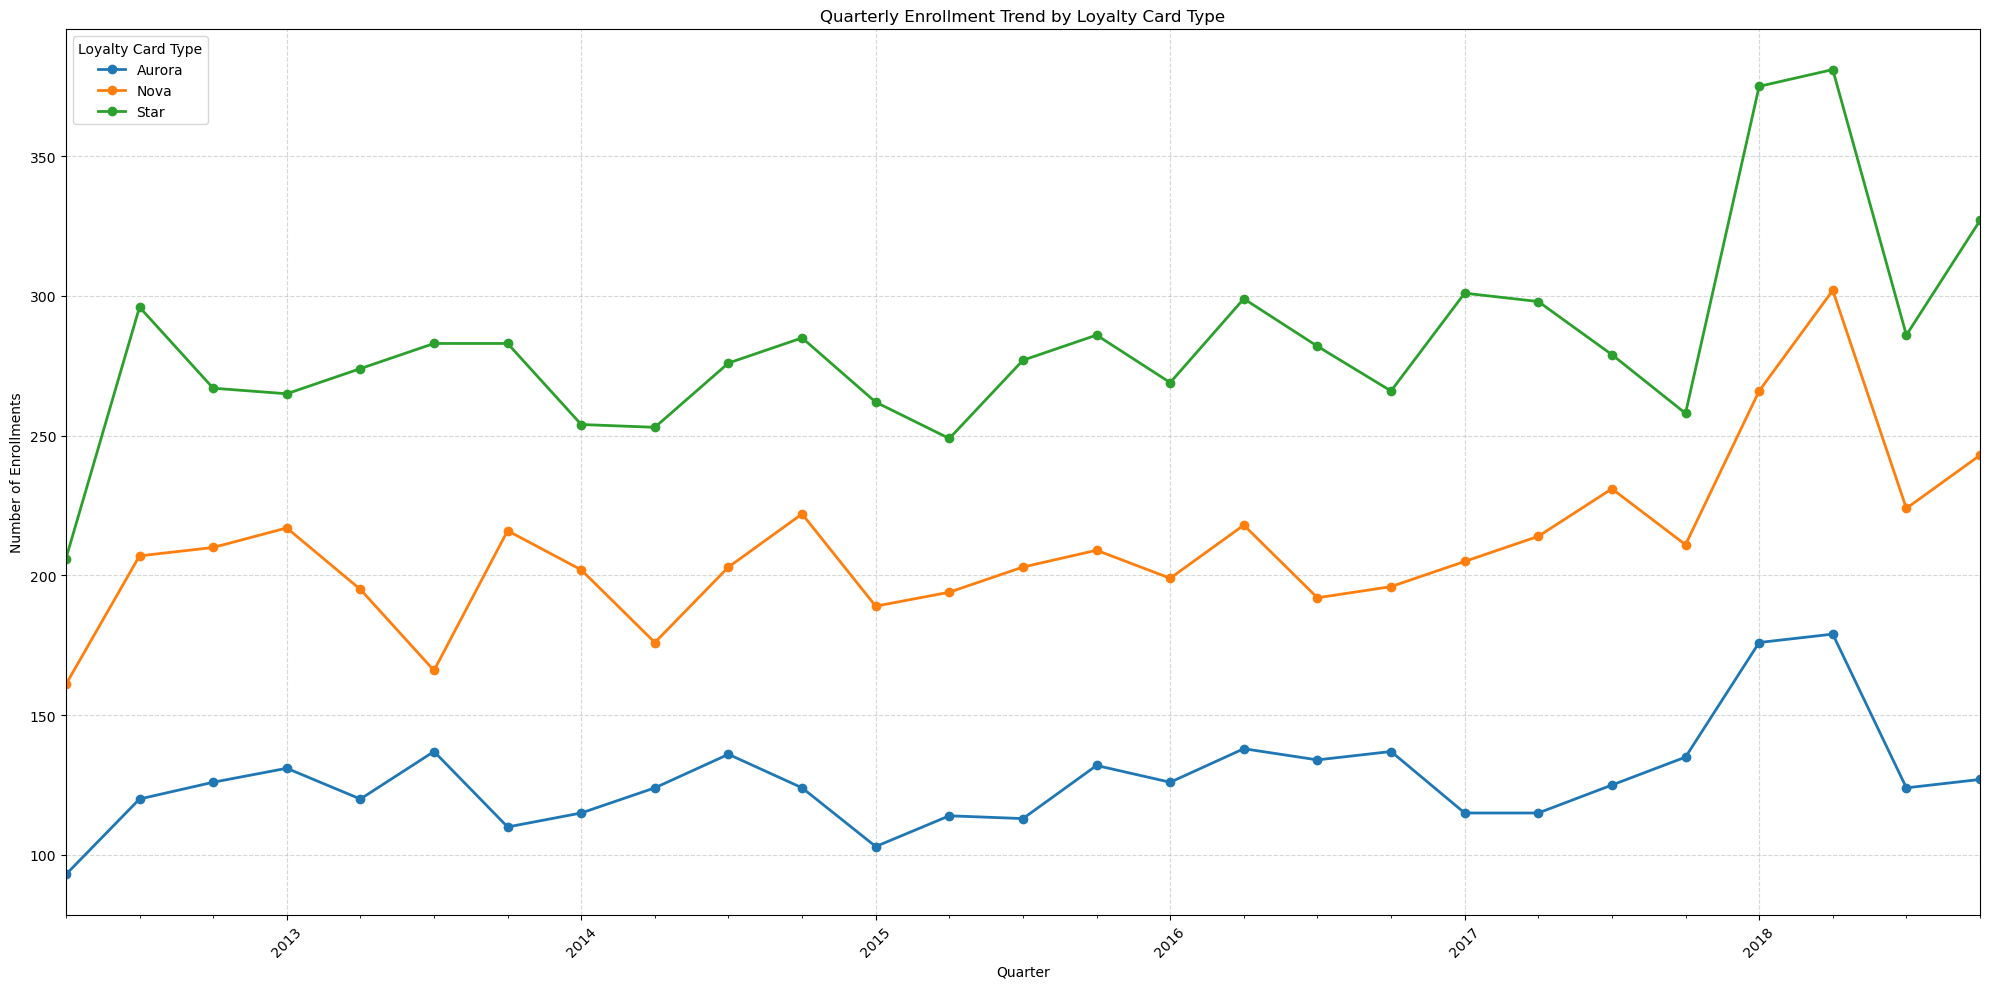

In [16]:
loyalty_data['enrollment_date'] = pd.to_datetime(loyalty_data['enrollment_date'], format='%Y-%m', errors='coerce')

loyalty_data['enrollment_quarter'] = loyalty_data['enrollment_date'].dt.to_period('Q')

# Group by quarter and loyalty card
quarterly_trend = (
    loyalty_data
    .groupby(['enrollment_quarter', 'loyalty_card'])
    .size()
    .reset_index(name='count')
)

# Pivot so each card type becomes a column
quarterly_pivot = quarterly_trend.pivot(index='enrollment_quarter', columns='loyalty_card', values='count').fillna(0)

# Convert PeriodIndex to timestamp for matplotlib compatibility
quarterly_pivot.index = quarterly_pivot.index.to_timestamp()

# Plot
ax = quarterly_pivot.plot(marker='o', linewidth=2, figsize=(20, 10))

ax.set_title('Quarterly Enrollment Trend by Loyalty Card Type')
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of Enrollments')
ax.legend(title='Loyalty Card Type')
ax.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Cancellation Trend by Card Type

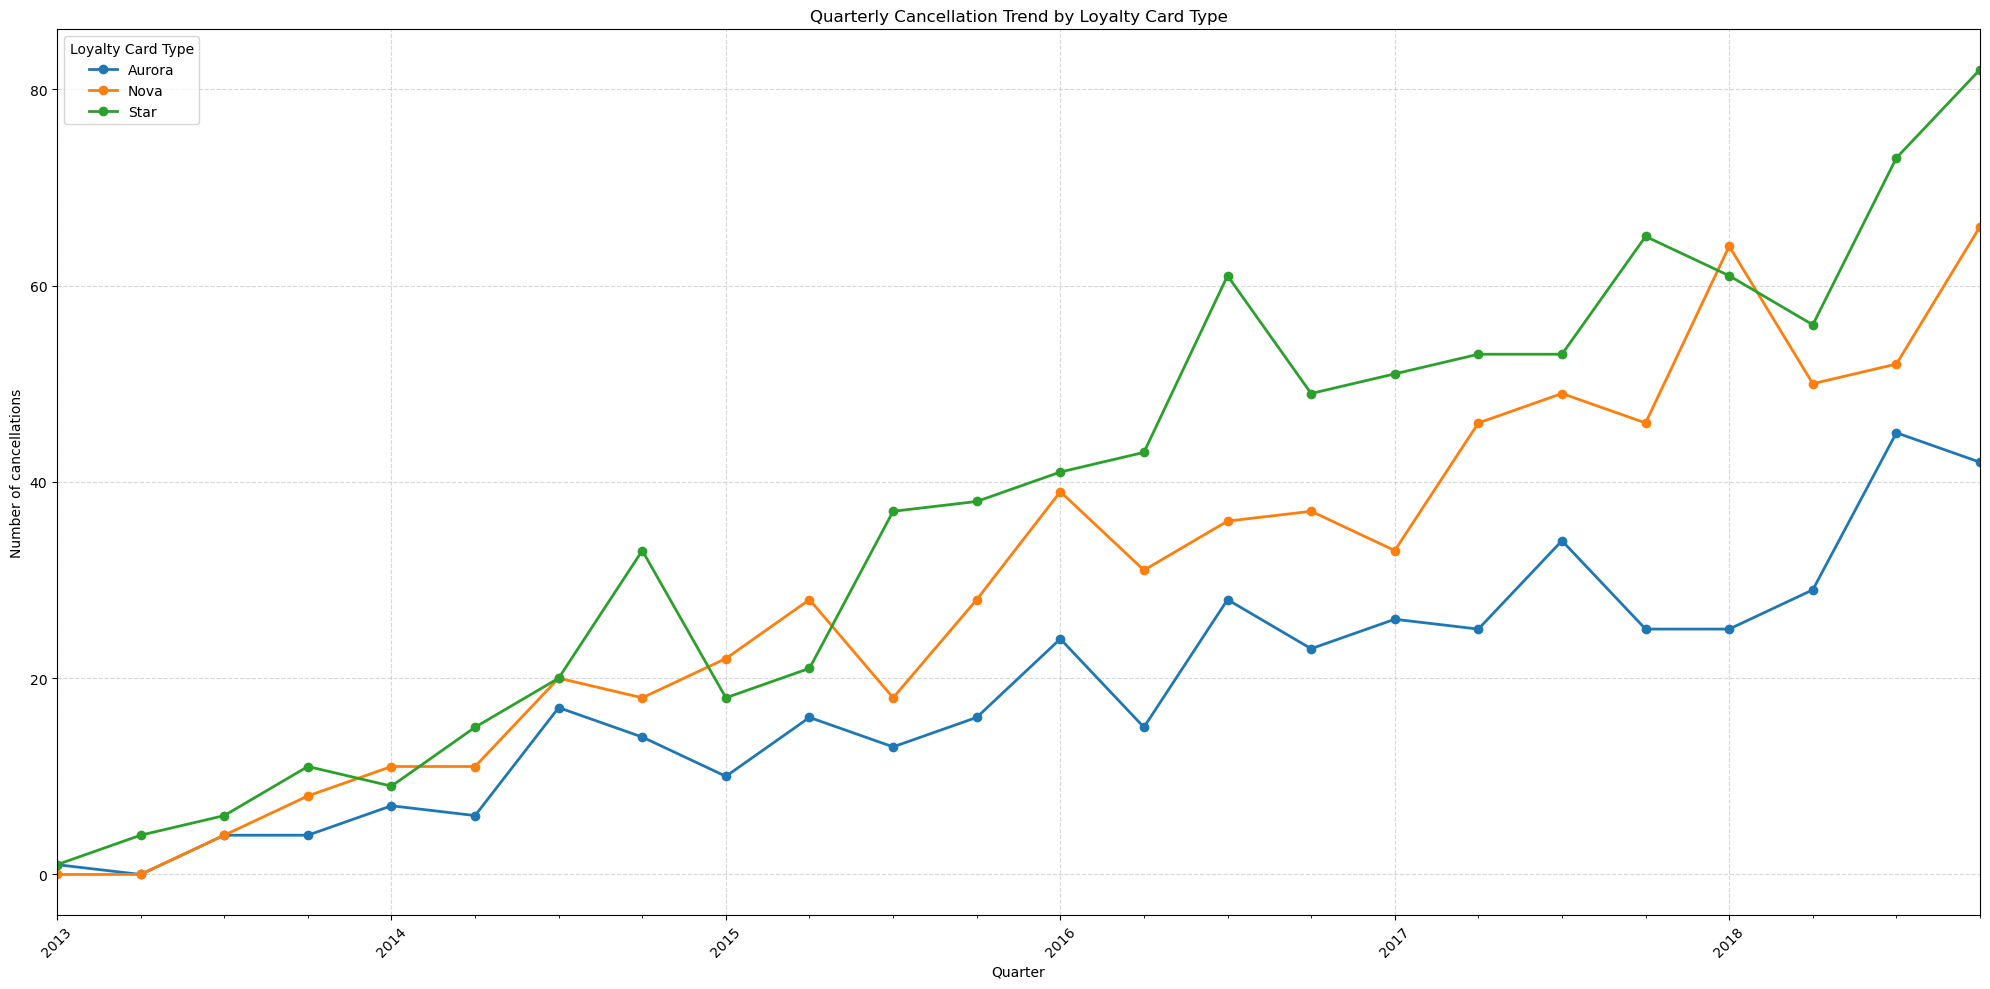

In [17]:
loyalty_data['cancellation_date'] = pd.to_datetime(loyalty_data['cancellation_date'], format='%Y-%m', errors='coerce')

loyalty_data['cancellation_quarter'] = loyalty_data['cancellation_date'].dt.to_period('Q')

# Group by quarter and loyalty card
quarterly_trend = (
    loyalty_data
    .groupby(['cancellation_quarter', 'loyalty_card'])
    .size()
    .reset_index(name='count')
)

# Pivot so each card type becomes a column
quarterly_pivot = quarterly_trend.pivot(index='cancellation_quarter', columns='loyalty_card', values='count').fillna(0)

# Convert PeriodIndex to timestamp for matplotlib compatibility
quarterly_pivot.index = quarterly_pivot.index.to_timestamp()

# Plot
ax = quarterly_pivot.plot(marker='o', linewidth=2, figsize=(20, 10))

ax.set_title('Quarterly Cancellation Trend by Loyalty Card Type')
ax.set_xlabel('Quarter')
ax.set_ylabel('Number of cancellations')
ax.legend(title='Loyalty Card Type')
ax.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Marital Status Analysis

In [18]:
clv_by_marital = (loyalty_data.groupby('marital_status')['clv']
                   .agg(['mean','median','count']).reset_index()
                   .round(2).sort_values(by = 'count', ascending=False))

clv_by_marital

,marital_status,mean,median,count
1,Married,8058.20,5824.77,9735
2,Single,7719.49,5583.07,4484
0,Divorced,8200.69,5872.96,2518


In [19]:
enrollment_by_status = (loyalty_data.groupby(['enrollment_year','marital_status']).size().unstack(fill_value=0))

enrollment_by_status

marital_status,Divorced,Married,Single
enrollment_year,,,
2012,254,979,453
2013,324,1411,662
2014,365,1357,648
2015,360,1342,629
2016,350,1465,641
2017,366,1464,657
2018,499,1717,794


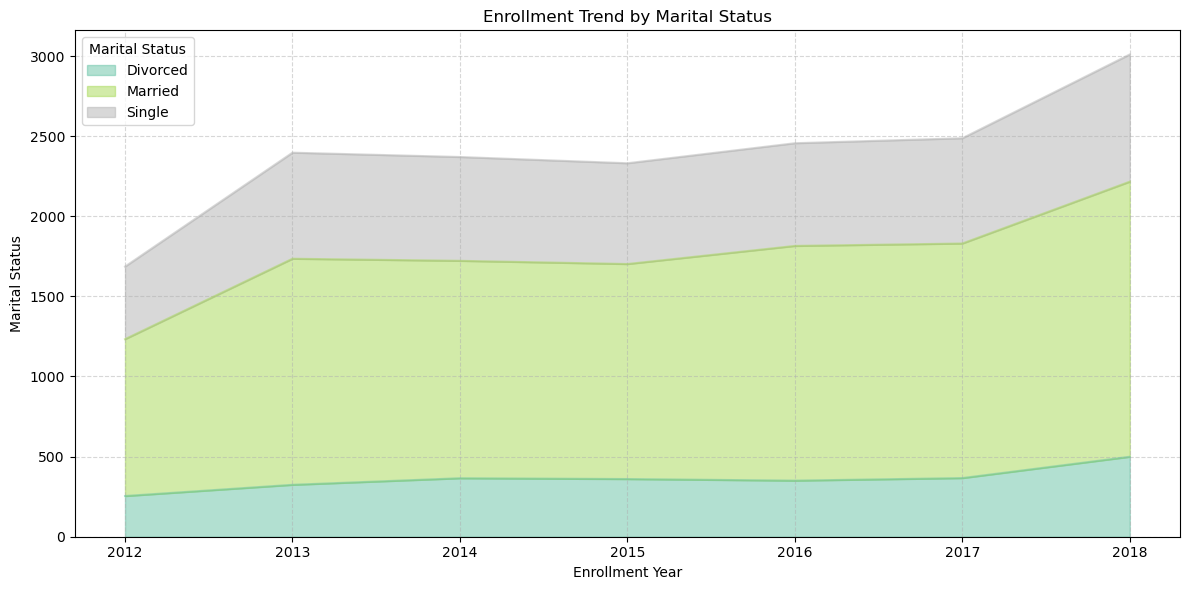

In [20]:
enrollment_by_status.plot(kind='area',stacked=True,figsize=(12,6),colormap='Set2', alpha = 0.5)

plt.title('Enrollment Trend by Marital Status')
plt.xlabel('Enrollment Year')
plt.ylabel('Marital Status')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.legend(title='Marital Status')
plt.show()

In [21]:
cardshare_by_status = (
    loyalty_data.groupby(['marital_status', 'loyalty_card'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: (100 * row / row.sum()).round(2), axis=1)
)

cardshare_by_status

loyalty_card,Aurora,Nova,Star
marital_status,,,
Divorced,20.02,33.72,46.27
Married,21.37,34.83,43.80
Single,18.84,31.91,49.24


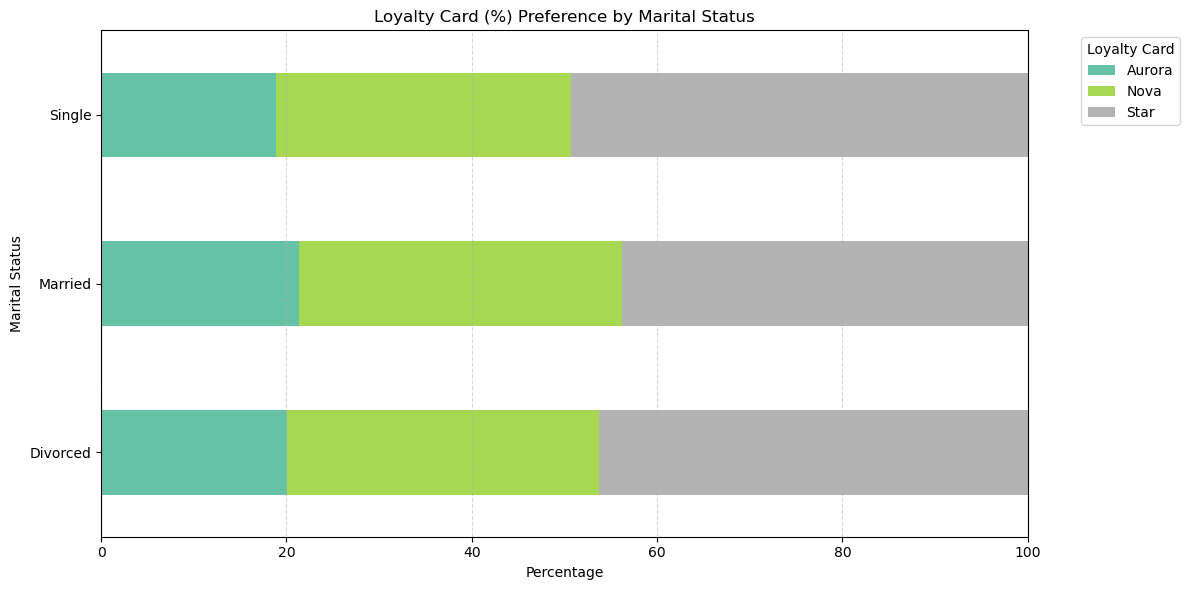

In [22]:
cardshare_by_status.plot(kind='barh', stacked=True, figsize=(12,6), colormap='Set2')

plt.title('Loyalty Card (%) Preference by Marital Status')
plt.xlabel('Percentage')
plt.ylabel('Marital Status')
plt.xlim(0,100)
plt.legend(title = 'Loyalty Card', bbox_to_anchor = (1.05,1), loc= 'upper left')
plt.grid(axis = 'x', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

In [23]:
cancellation_by_status = (loyalty_data.groupby(['cancellation_year','marital_status']).size().unstack(fill_value=0))

# Remove the row where cancellation_year == 0
cancellation_by_status = cancellation_by_status.loc[cancellation_by_status.index != 0]

cancellation_by_status

marital_status,Divorced,Married,Single
cancellation_year,,,
2013,9,24,10
2014,30,103,48
2015,31,172,62
2016,56,263,108
2017,70,276,160
2018,95,376,174


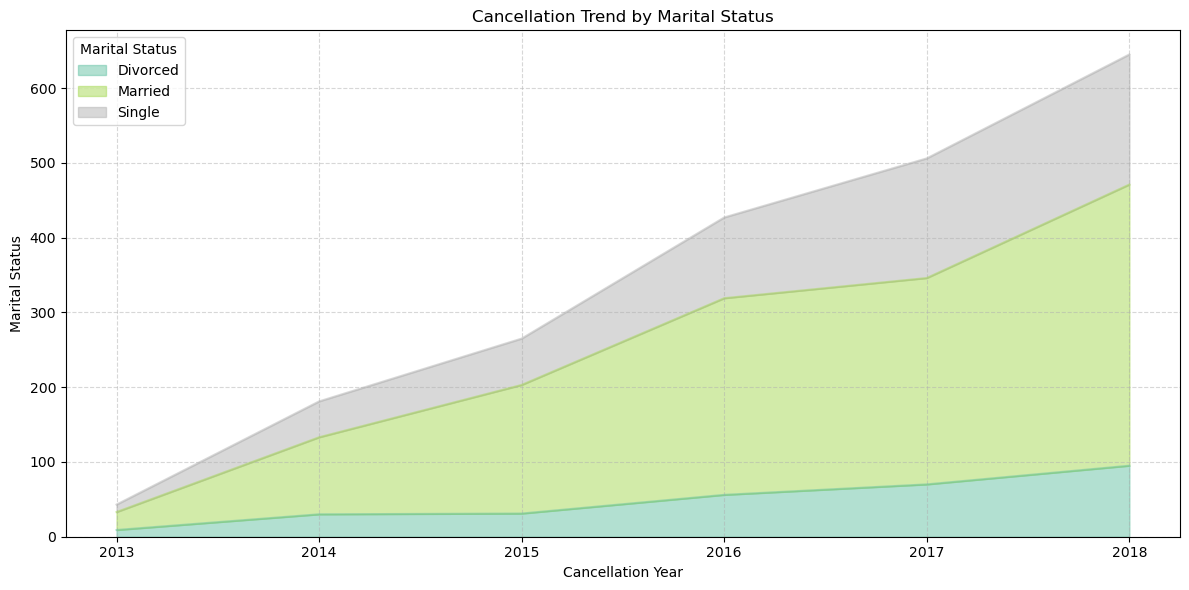

In [24]:
cancellation_by_status.plot(kind='area',stacked=True,figsize=(12,6),colormap='Set2', alpha = 0.5)

plt.title('Cancellation Trend by Marital Status')
plt.xlabel('Cancellation Year')
plt.ylabel('Marital Status')
plt.grid(True, linestyle='--', alpha = 0.5)
plt.tight_layout()
plt.legend(title='Marital Status')
plt.show()  